In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
from sklearn.datasets import load_breast_cancer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [5]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [7]:
print("="*70)
print("HEART DISEASE PREDICTION")
print("="*70)

HEART DISEASE PREDICTION


In [8]:
heart_df = pd.read_csv('heart.csv')
print("Heart disease dataset loaded from 'heart.csv'")

Heart disease dataset loaded from 'heart.csv'


In [9]:
print(f"\nDataset shape: {heart_df.shape}")


Dataset shape: (303, 14)


In [10]:
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [11]:
print("\n" + "-"*50)
print("HEART DISEASE - EXPLORATORY DATA ANALYSIS")
print("-"*50)


--------------------------------------------------
HEART DISEASE - EXPLORATORY DATA ANALYSIS
--------------------------------------------------


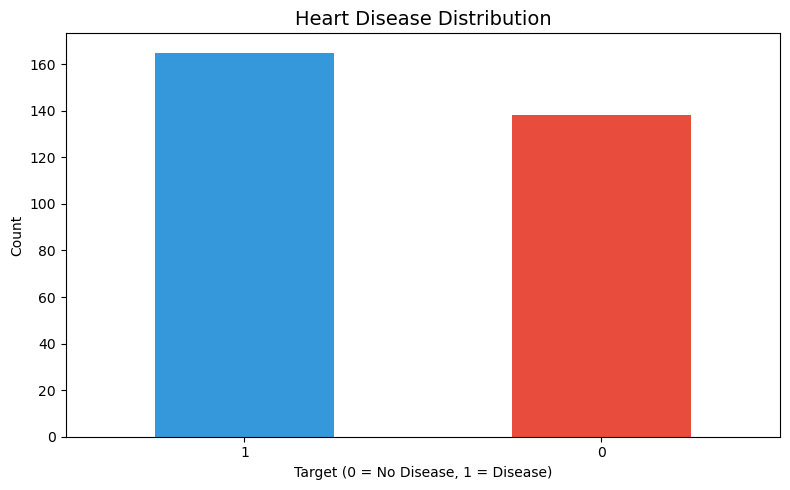

In [12]:
plt.figure(figsize=(8, 5))
heart_df['target'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Heart Disease Distribution', fontsize=14)
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('heart_disease_distribution.png', dpi=150)
plt.show()

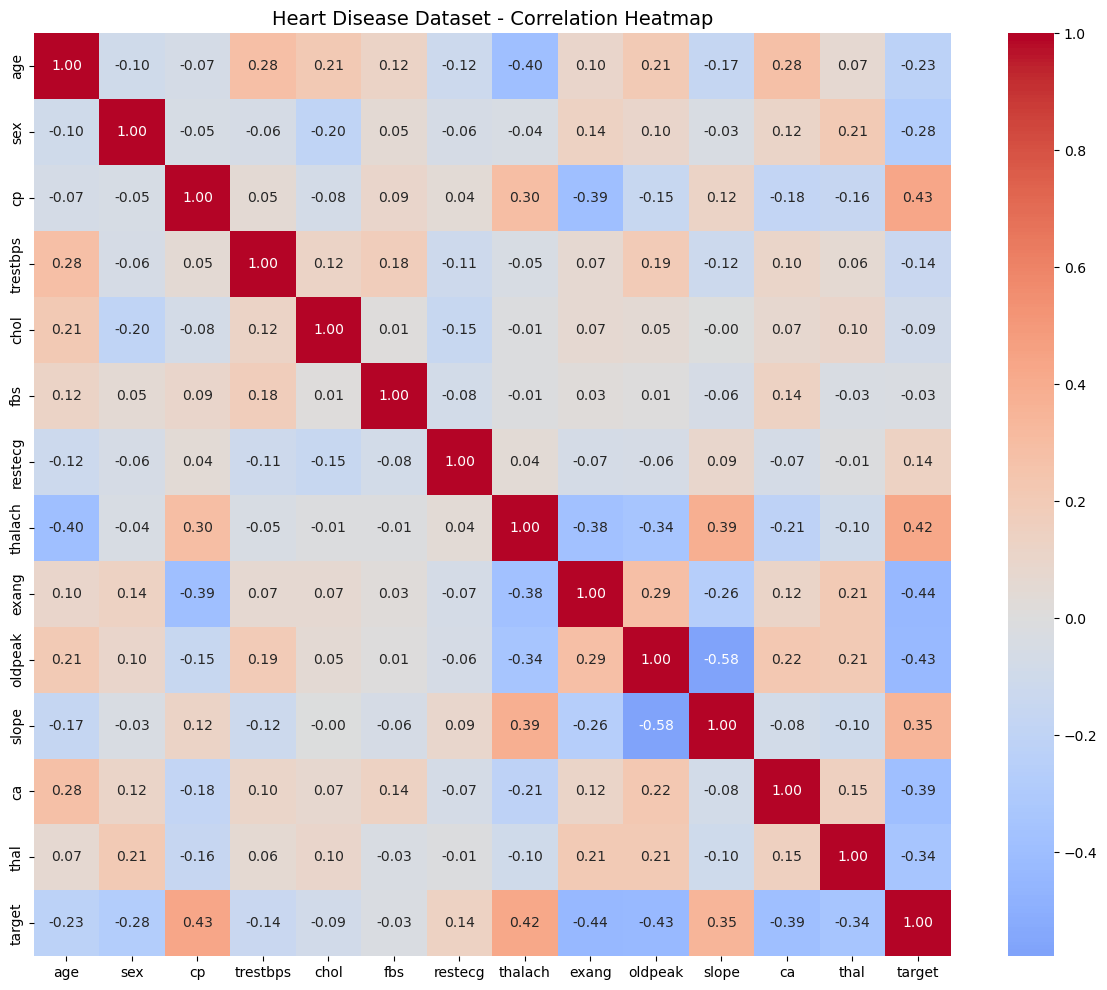

In [13]:
plt.figure(figsize=(12, 10))
sns.heatmap(heart_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heart Disease Dataset - Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('heart_correlation.png', dpi=150)
plt.show()

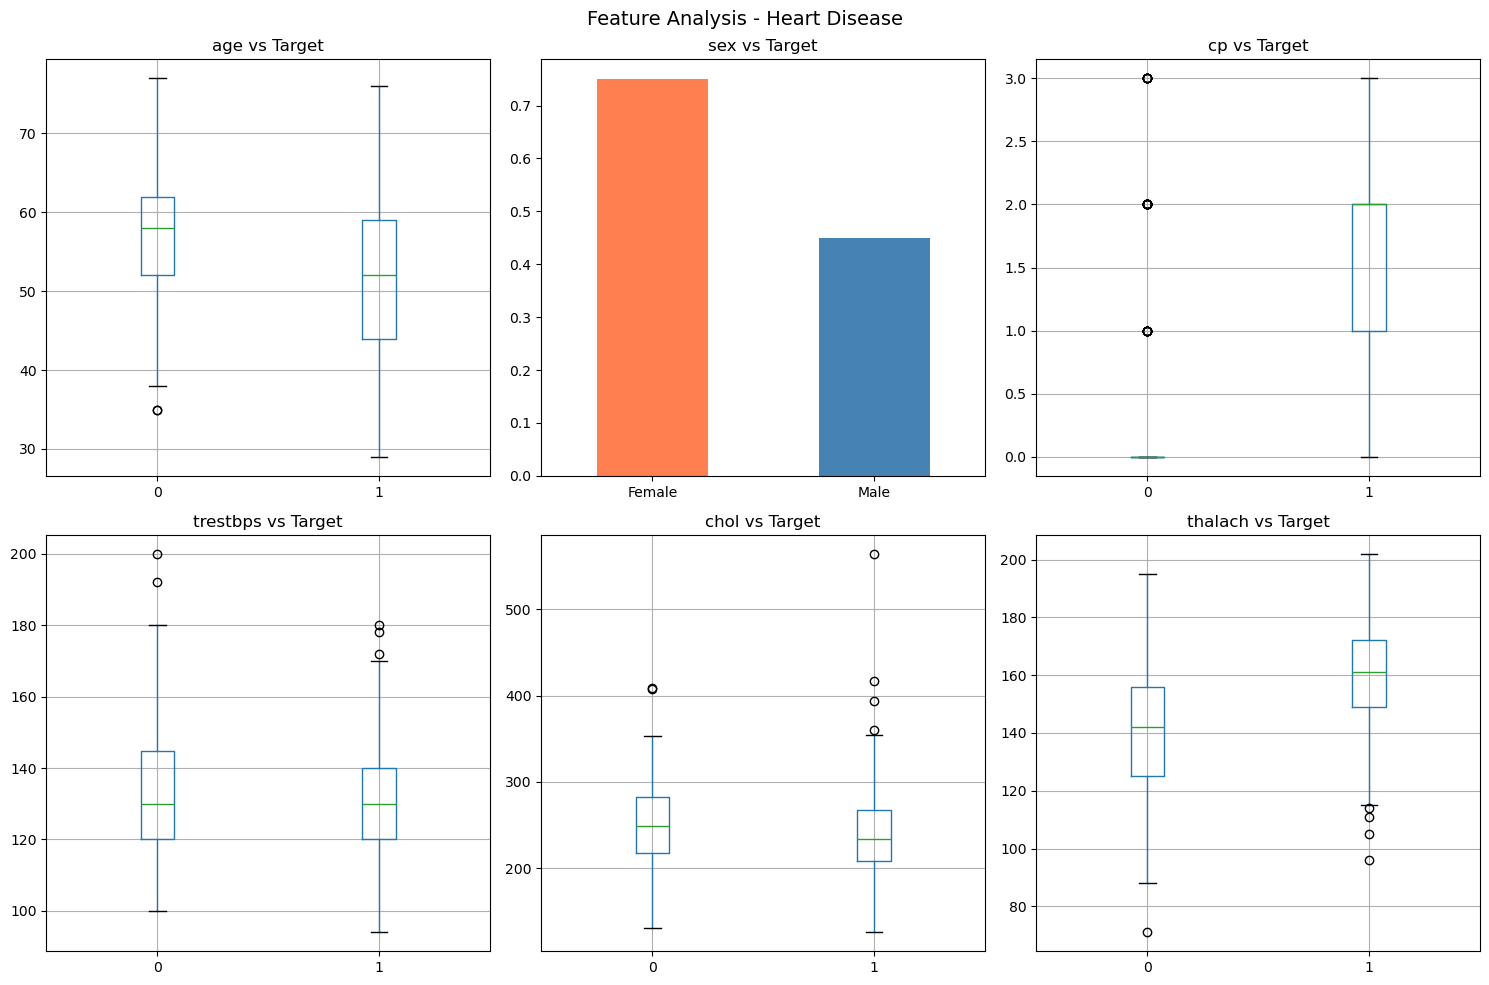

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features_to_plot = ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach']
for idx, feature in enumerate(features_to_plot):
    if feature == 'sex':
        heart_df.groupby('sex')['target'].mean().plot(kind='bar', ax=axes[idx], color=['coral', 'steelblue'])
        axes[idx].set_xticklabels(['Female', 'Male'], rotation=0)
    else:
        heart_df.boxplot(column=feature, by='target', ax=axes[idx])
    axes[idx].set_title(f'{feature} vs Target')
    axes[idx].set_xlabel('')

plt.suptitle('Feature Analysis - Heart Disease', fontsize=14)
plt.tight_layout()
plt.savefig('heart_feature_analysis.png', dpi=150)
plt.show()

In [16]:
print("\n" + "="*70)
print("DIABETES PREDICTION")
print("="*70)


DIABETES PREDICTION


In [17]:
diabetes_df = pd.read_csv('diabetes.csv')
print("Diabetes dataset loaded from 'diabetes.csv'")

Diabetes dataset loaded from 'diabetes.csv'


In [18]:
print(f"\nDataset shape: {diabetes_df.shape}")


Dataset shape: (768, 9)


In [19]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


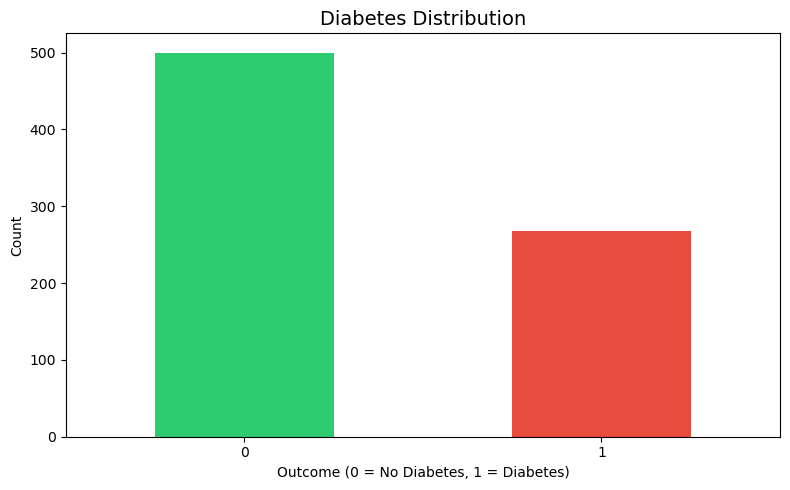

In [20]:
plt.figure(figsize=(8, 5))
diabetes_df['Outcome'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Diabetes Distribution', fontsize=14)
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('diabetes_distribution.png', dpi=150)
plt.show()

In [21]:
print("\n" + "="*70)
print("BREAST CANCER PREDICTION")
print("="*70)


BREAST CANCER PREDICTION


In [22]:
cancer = load_breast_cancer()
cancer_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
cancer_df['target'] = cancer.target

In [23]:
print(f"Dataset shape: {cancer_df.shape}")
print(f"Features: {cancer.feature_names[:5]}...")
print(f"Classes: {cancer.target_names}")
print(f"Class distribution: {dict(zip(cancer.target_names, np.bincount(cancer.target)))}")

Dataset shape: (569, 31)
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...
Classes: ['malignant' 'benign']
Class distribution: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


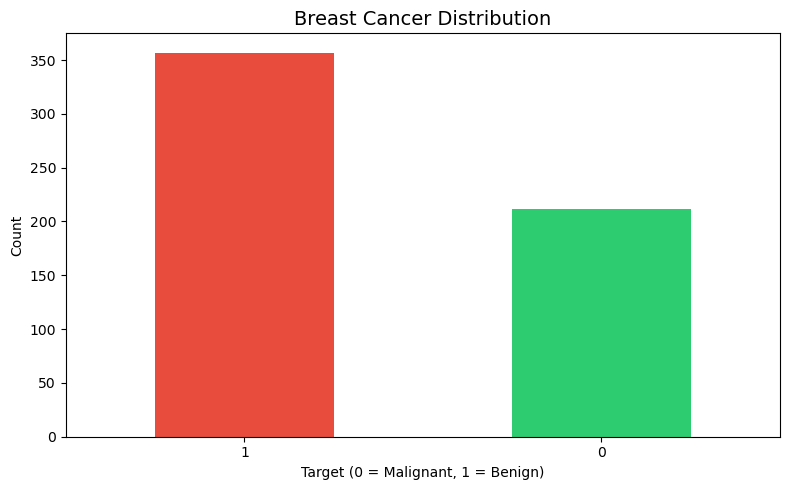

In [24]:
plt.figure(figsize=(8, 5))
pd.Series(cancer.target).value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Breast Cancer Distribution', fontsize=14)
plt.xlabel('Target (0 = Malignant, 1 = Benign)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cancer_distribution.png', dpi=150)
plt.show()

In [26]:
def preprocess_dataset(df, target_col, test_size=0.2):
   
    X = df.drop(target_col, axis=1)
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, X.columns

In [27]:
print("\n" + "="*70)
print("PREPROCESSING ALL DATASETS")
print("="*70)


PREPROCESSING ALL DATASETS


In [28]:
X_train_h, X_test_h, y_train_h, y_test_h, scaler_h, features_h = preprocess_dataset(
    heart_df, 'target'
)
print(f"Heart Disease - Train: {X_train_h.shape}, Test: {X_test_h.shape}")

Heart Disease - Train: (242, 13), Test: (61, 13)


In [29]:
X_train_d, X_test_d, y_train_d, y_test_d, scaler_d, features_d = preprocess_dataset(
    diabetes_df, 'Outcome'
)
print(f"Diabetes - Train: {X_train_d.shape}, Test: {X_test_d.shape}")

Diabetes - Train: (614, 8), Test: (154, 8)


In [30]:
X_train_c, X_test_c, y_train_c, y_test_c, scaler_c, features_c = preprocess_dataset(
    cancer_df, 'target'
)
print(f"Breast Cancer - Train: {X_train_c.shape}, Test: {X_test_c.shape}")

Breast Cancer - Train: (455, 30), Test: (114, 30)


In [33]:
def get_models():
    """Return dictionary of classification models."""
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'SVM (RBF)': SVC(probability=True, random_state=RANDOM_STATE, kernel='rbf'),
        'SVM (Linear)': SVC(probability=True, random_state=RANDOM_STATE, kernel='linear'),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, max_depth=15),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'XGBoost': XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='logloss'),
        'LightGBM': LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1),
        'Naive Bayes': GaussianNB(),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
    }

In [34]:
def train_and_evaluate_models(X_train, X_test, y_train, y_test, dataset_name, feature_names):
    
    print(f"\n{'='*60}")
    print(f"TRAINING MODELS FOR: {dataset_name}")
    print(f"{'='*60}")

    models = get_models()
    results = []
    predictions = {}
    trained_models = {}

    for name, model in models.items():
        print(f"\nTraining {name}...")

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        result = {
            'Dataset': dataset_name,
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else None
        }

        results.append(result)
        predictions[name] = (y_pred, y_prob)
        trained_models[name] = model

        print(f"  Accuracy: {result['Accuracy']:.4f} | F1: {result['F1-Score']:.4f} | AUC: {result['ROC-AUC']:.4f}" if result['ROC-AUC'] else f"  Accuracy: {result['Accuracy']:.4f} | F1: {result['F1-Score']:.4f}")

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('ROC-AUC', ascending=False)

    # Get best model
    best_model_name = results_df.iloc[0]['Model']
    best_model = trained_models[best_model_name]

    print(f"\nBest Model: {best_model_name}")
    print(f"Best ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")

    return results_df, best_model, predictions, trained_models

In [35]:
results_h, best_h, preds_h, models_h = train_and_evaluate_models(
    X_train_h, X_test_h, y_train_h, y_test_h, 
    'Heart Disease', features_h
)


TRAINING MODELS FOR: Heart Disease

Training Logistic Regression...
  Accuracy: 0.8033 | F1: 0.8333 | AUC: 0.8690

Training SVM (RBF)...
  Accuracy: 0.8197 | F1: 0.8493 | AUC: 0.8831

Training SVM (Linear)...
  Accuracy: 0.7869 | F1: 0.8219 | AUC: 0.8842

Training Decision Tree...
  Accuracy: 0.7049 | F1: 0.7429 | AUC: 0.6975

Training Random Forest...
  Accuracy: 0.8197 | F1: 0.8533 | AUC: 0.9123

Training Gradient Boosting...
  Accuracy: 0.8033 | F1: 0.8286 | AUC: 0.8658

Training XGBoost...
  Accuracy: 0.7869 | F1: 0.8267 | AUC: 0.8463

Training LightGBM...
  Accuracy: 0.8197 | F1: 0.8451 | AUC: 0.8604

Training Naive Bayes...
  Accuracy: 0.8197 | F1: 0.8451 | AUC: 0.8755

Training K-Nearest Neighbors...
  Accuracy: 0.8033 | F1: 0.8333 | AUC: 0.8631

Best Model: Random Forest
Best ROC-AUC: 0.9123


In [36]:
results_d, best_d, preds_d, models_d = train_and_evaluate_models(
    X_train_d, X_test_d, y_train_d, y_test_d,
    'Diabetes', features_d
)


TRAINING MODELS FOR: Diabetes

Training Logistic Regression...
  Accuracy: 0.7143 | F1: 0.5600 | AUC: 0.8230

Training SVM (RBF)...
  Accuracy: 0.7532 | F1: 0.6346 | AUC: 0.7924

Training SVM (Linear)...
  Accuracy: 0.7208 | F1: 0.5657 | AUC: 0.8281

Training Decision Tree...
  Accuracy: 0.7273 | F1: 0.5532 | AUC: 0.7319

Training Random Forest...
  Accuracy: 0.7532 | F1: 0.6346 | AUC: 0.8125

Training Gradient Boosting...
  Accuracy: 0.7532 | F1: 0.6415 | AUC: 0.8335

Training XGBoost...
  Accuracy: 0.7273 | F1: 0.6038 | AUC: 0.8017

Training LightGBM...
  Accuracy: 0.7078 | F1: 0.5714 | AUC: 0.8098

Training Naive Bayes...
  Accuracy: 0.7078 | F1: 0.6087 | AUC: 0.7728

Training K-Nearest Neighbors...
  Accuracy: 0.7013 | F1: 0.5490 | AUC: 0.7405

Best Model: Gradient Boosting
Best ROC-AUC: 0.8335


In [37]:
results_c, best_c, preds_c, models_c = train_and_evaluate_models(
    X_train_c, X_test_c, y_train_c, y_test_c,
    'Breast Cancer', features_c
)


TRAINING MODELS FOR: Breast Cancer

Training Logistic Regression...
  Accuracy: 0.9825 | F1: 0.9861 | AUC: 0.9954

Training SVM (RBF)...
  Accuracy: 0.9825 | F1: 0.9861 | AUC: 0.9950

Training SVM (Linear)...
  Accuracy: 0.9737 | F1: 0.9790 | AUC: 0.9964

Training Decision Tree...
  Accuracy: 0.9123 | F1: 0.9286 | AUC: 0.9157

Training Random Forest...
  Accuracy: 0.9561 | F1: 0.9655 | AUC: 0.9932

Training Gradient Boosting...
  Accuracy: 0.9561 | F1: 0.9660 | AUC: 0.9897

Training XGBoost...
  Accuracy: 0.9561 | F1: 0.9660 | AUC: 0.9934

Training LightGBM...
  Accuracy: 0.9561 | F1: 0.9660 | AUC: 0.9874

Training Naive Bayes...
  Accuracy: 0.9298 | F1: 0.9444 | AUC: 0.9868

Training K-Nearest Neighbors...
  Accuracy: 0.9561 | F1: 0.9655 | AUC: 0.9788

Best Model: SVM (Linear)
Best ROC-AUC: 0.9964


In [38]:
print("\n" + "="*70)
print("COMBINED RESULTS ACROSS ALL DATASETS")
print("="*70)


COMBINED RESULTS ACROSS ALL DATASETS


In [40]:
all_results = pd.concat([results_h, results_d, results_c], ignore_index=True)
print("\nTop 3 Models per Dataset (by ROC-AUC):")
print("-"*70)

for dataset in ['Heart Disease', 'Diabetes', 'Breast Cancer']:
    subset = all_results[all_results['Dataset'] == dataset].head(3)
    print(f"\n{dataset}:")
    print(subset[['Model', 'Accuracy', 'F1-Score', 'ROC-AUC']].to_string(index=False))


Top 3 Models per Dataset (by ROC-AUC):
----------------------------------------------------------------------

Heart Disease:
        Model  Accuracy  F1-Score  ROC-AUC
Random Forest  0.819672  0.853333 0.912338
 SVM (Linear)  0.786885  0.821918 0.884199
    SVM (RBF)  0.819672  0.849315 0.883117

Diabetes:
              Model  Accuracy  F1-Score  ROC-AUC
  Gradient Boosting  0.753247  0.641509 0.833519
       SVM (Linear)  0.720779  0.565657 0.828056
Logistic Regression  0.714286  0.560000 0.822963

Breast Cancer:
              Model  Accuracy  F1-Score  ROC-AUC
       SVM (Linear)  0.973684  0.979021 0.996362
Logistic Regression  0.982456  0.986111 0.995370
          SVM (RBF)  0.982456  0.986111 0.995040


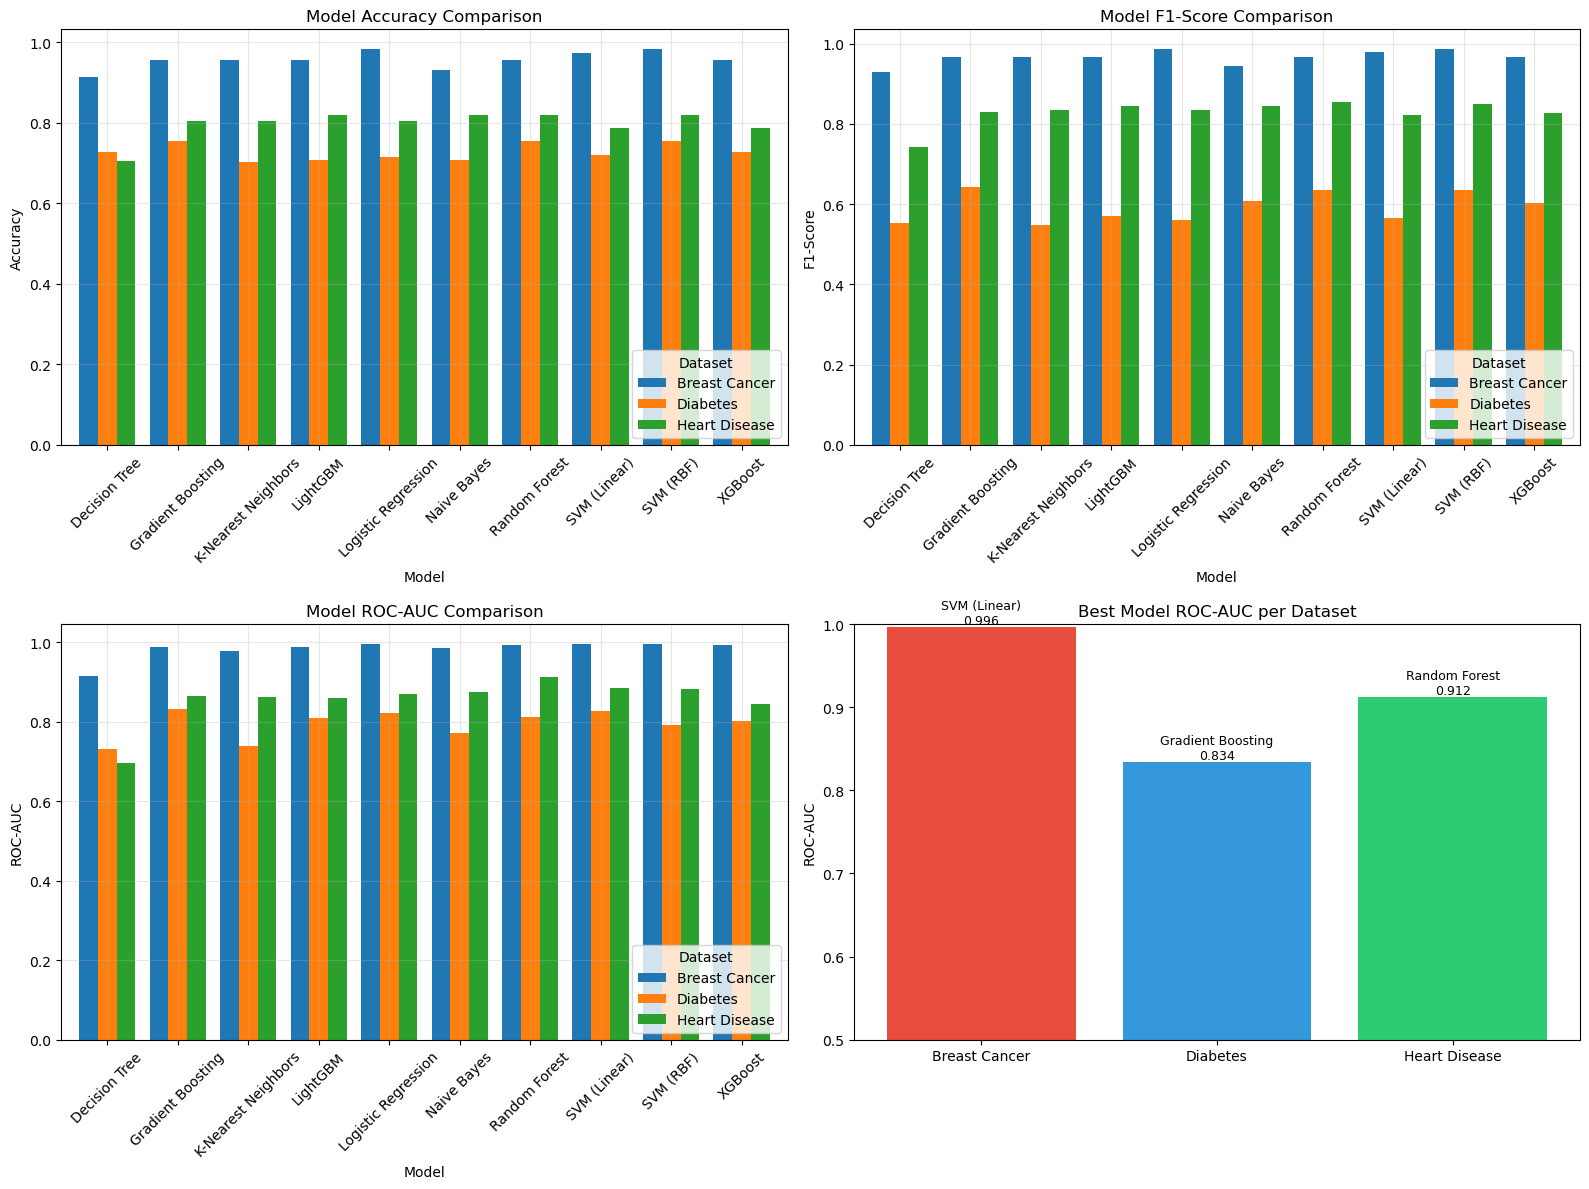

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Model Comparison - Accuracy
ax = axes[0, 0]
pivot_acc = all_results.pivot(index='Model', columns='Dataset', values='Accuracy')
pivot_acc.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Accuracy Comparison', fontsize=12)
ax.set_ylabel('Accuracy')
ax.legend(title='Dataset', loc='lower right')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Plot 2: Model Comparison - F1-Score
ax = axes[0, 1]
pivot_f1 = all_results.pivot(index='Model', columns='Dataset', values='F1-Score')
pivot_f1.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model F1-Score Comparison', fontsize=12)
ax.set_ylabel('F1-Score')
ax.legend(title='Dataset', loc='lower right')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Plot 3: Model Comparison - ROC-AUC
ax = axes[1, 0]
pivot_auc = all_results.pivot(index='Model', columns='Dataset', values='ROC-AUC')
pivot_auc.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model ROC-AUC Comparison', fontsize=12)
ax.set_ylabel('ROC-AUC')
ax.legend(title='Dataset', loc='lower right')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Plot 4: Best Model per Dataset
ax = axes[1, 1]
best_per_dataset = all_results.loc[all_results.groupby('Dataset')['ROC-AUC'].idxmax()]
bars = ax.bar(best_per_dataset['Dataset'], best_per_dataset['ROC-AUC'], 
              color=['#e74c3c', '#3498db', '#2ecc71'])
ax.set_title('Best Model ROC-AUC per Dataset', fontsize=12)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 1.0)

for i, (bar, model) in enumerate(zip(bars, best_per_dataset['Model'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{model}\n{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_all_datasets.png', dpi=150)
plt.show()

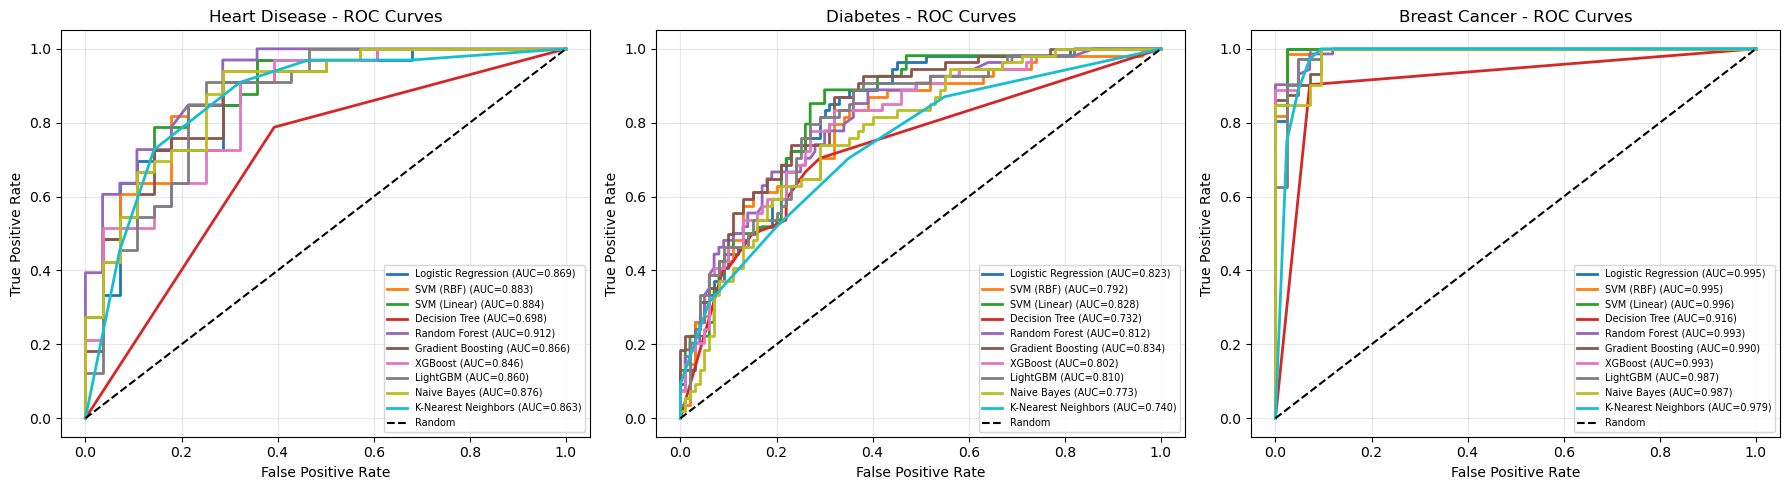

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets_info = [
    ('Heart Disease', y_test_h, preds_h, models_h),
    ('Diabetes', y_test_d, preds_d, models_d),
    ('Breast Cancer', y_test_c, preds_c, models_c)
]

for idx, (name, y_test, preds, models) in enumerate(datasets_info):
    ax = axes[idx]

    for model_name, (y_pred, y_prob) in preds.items():
        if y_prob is not None:
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)
            ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_title(f'{name} - ROC Curves')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_all_datasets.png', dpi=150)
plt.show()

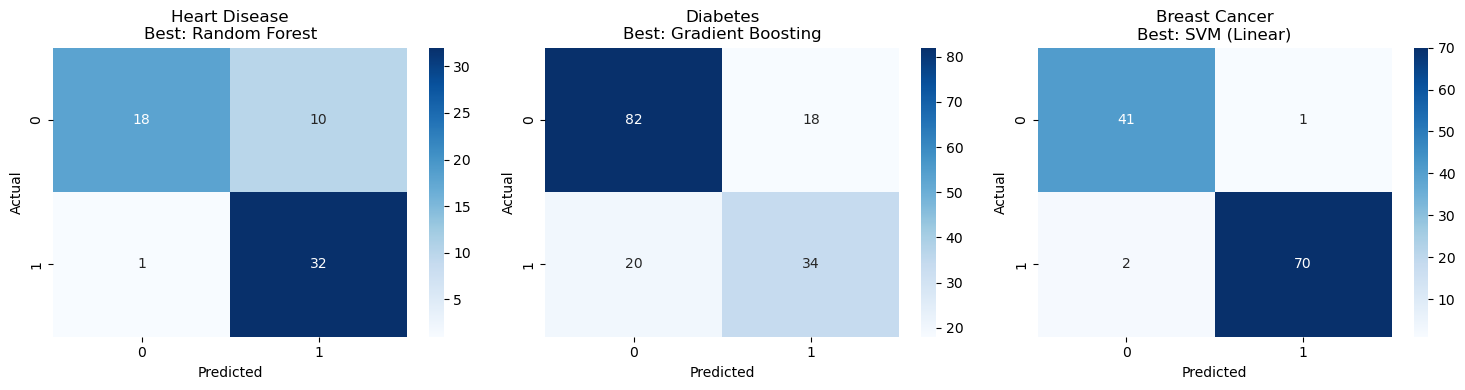

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_test, preds, models) in enumerate(datasets_info):
    ax = axes[idx]

    # Get best model predictions
    best_name = all_results[all_results['Dataset'] == name].iloc[0]['Model']
    best_pred, _ = preds[best_name]

    cm = confusion_matrix(y_test, best_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}\nBest: {best_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices_best_models.png', dpi=150)
plt.show()

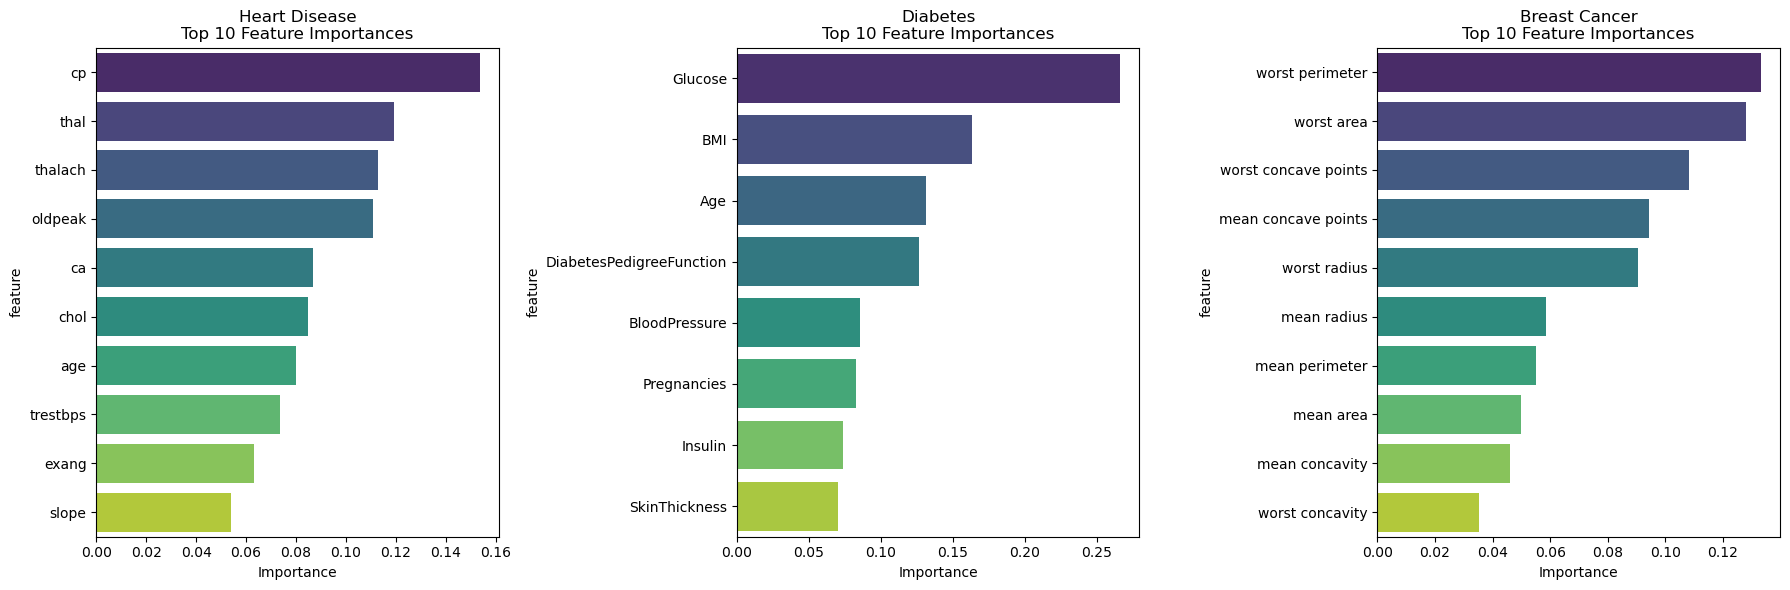

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets_features = [
    ('Heart Disease', models_h['Random Forest'], features_h),
    ('Diabetes', models_d['Random Forest'], features_d),
    ('Breast Cancer', models_c['Random Forest'], features_c)
]

for idx, (name, model, features) in enumerate(datasets_features):
    ax = axes[idx]

    importance = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    sns.barplot(data=importance, x='importance', y='feature', ax=ax, palette='viridis')
    ax.set_title(f'{name}\nTop 10 Feature Importances')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance_all_datasets.png', dpi=150)
plt.show()

In [48]:
print("\n" + "="*70)
print("ENSEMBLE MODEL - VOTING CLASSIFIER")
print("="*70)


ENSEMBLE MODEL - VOTING CLASSIFIER


In [49]:
def build_ensemble(X_train, X_test, y_train, y_test, dataset_name):
    """Build and evaluate a voting ensemble of top models."""

    # Select top 3 models for ensemble
    estimators = [
        ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
        ('xgb', XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='logloss')),
        ('lgbm', LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1))
    ]

    ensemble = VotingClassifier(estimators=estimators, voting='soft')
    ensemble.fit(X_train, y_train)

    y_pred = ensemble.predict(X_test)
    y_prob = ensemble.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{dataset_name} - Ensemble Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC:  {auc:.4f}")

    return ensemble, accuracy, f1, auc

In [50]:
ensemble_h, acc_h, f1_h, auc_h = build_ensemble(
    X_train_h, X_test_h, y_train_h, y_test_h, 'Heart Disease'
)
ensemble_d, acc_d, f1_d, auc_d = build_ensemble(
    X_train_d, X_test_d, y_train_d, y_test_d, 'Diabetes'
)
ensemble_c, acc_c, f1_c, auc_c = build_ensemble(
    X_train_c, X_test_c, y_train_c, y_test_c, 'Breast Cancer'
)


Heart Disease - Ensemble Results:
  Accuracy: 0.8197
  F1-Score: 0.8493
  ROC-AUC:  0.8853

Diabetes - Ensemble Results:
  Accuracy: 0.7078
  F1-Score: 0.5714
  ROC-AUC:  0.8109

Breast Cancer - Ensemble Results:
  Accuracy: 0.9561
  F1-Score: 0.9660
  ROC-AUC:  0.9950


In [51]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING - RANDOM FOREST (Heart Disease)")
print("="*70)


HYPERPARAMETER TUNING - RANDOM FOREST (Heart Disease)


In [52]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [54]:
param_grid_small = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5]
}

print("Running Grid Search for Random Forest...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_small,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_h, y_train_h)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Running Grid Search for Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.9066


In [55]:
best_tuned = grid_search.best_estimator_
tuned_pred = best_tuned.predict(X_test_h)
tuned_prob = best_tuned.predict_proba(X_test_h)[:, 1]

print(f"\nTuned Model Test Results:")
print(f"Accuracy: {accuracy_score(y_test_h, tuned_pred):.4f}")
print(f"F1-Score: {f1_score(y_test_h, tuned_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_h, tuned_prob):.4f}")


Tuned Model Test Results:
Accuracy: 0.8197
F1-Score: 0.8493
ROC-AUC: 0.9102


In [56]:
import joblib

# Save all best models
joblib.dump(best_h, 'best_heart_disease_model.pkl')
joblib.dump(best_d, 'best_diabetes_model.pkl')
joblib.dump(best_c, 'best_breast_cancer_model.pkl')
joblib.dump(ensemble_h, 'ensemble_heart_disease.pkl')
joblib.dump(ensemble_d, 'ensemble_diabetes.pkl')
joblib.dump(ensemble_c, 'ensemble_breast_cancer.pkl')
joblib.dump(scaler_h, 'scaler_heart_disease.pkl')
joblib.dump(scaler_d, 'scaler_diabetes.pkl')
joblib.dump(scaler_c, 'scaler_breast_cancer.pkl')

print("\n" + "="*70)
print("SAVED MODELS")
print("="*70)
print("- best_heart_disease_model.pkl")
print("- best_diabetes_model.pkl")
print("- best_breast_cancer_model.pkl")
print("- ensemble_heart_disease.pkl")
print("- ensemble_diabetes.pkl")
print("- ensemble_breast_cancer.pkl")
print("- scaler_heart_disease.pkl")
print("- scaler_diabetes.pkl")
print("- scaler_breast_cancer.pkl")


SAVED MODELS
- best_heart_disease_model.pkl
- best_diabetes_model.pkl
- best_breast_cancer_model.pkl
- ensemble_heart_disease.pkl
- ensemble_diabetes.pkl
- ensemble_breast_cancer.pkl
- scaler_heart_disease.pkl
- scaler_diabetes.pkl
- scaler_breast_cancer.pkl


In [57]:
def predict_heart_disease(patient_data):
   
    features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
                'restecg', 'thalach', 'exang', 'oldpeak', 
                'slope', 'ca', 'thal']

    input_df = pd.DataFrame([patient_data])[features]
    input_scaled = scaler_h.transform(input_df)

    prob = ensemble_h.predict_proba(input_scaled)[0][1]
    pred = ensemble_h.predict(input_scaled)[0]

    risk_level = "HIGH" if prob > 0.7 else "MEDIUM" if prob > 0.4 else "LOW"

    return {
        'disease_probability': round(prob, 4),
        'prediction': 'Heart Disease Detected' if pred == 1 else 'No Heart Disease',
        'risk_level': risk_level,
        'recommendation': 'Consult cardiologist immediately' if prob > 0.7 else 'Regular checkup recommended' if prob > 0.4 else 'Low risk, maintain healthy lifestyle'
    }

In [58]:
def predict_diabetes(patient_data):
    """Predict diabetes risk for a patient."""
    features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

    input_df = pd.DataFrame([patient_data])[features]
    input_scaled = scaler_d.transform(input_df)

    prob = ensemble_d.predict_proba(input_scaled)[0][1]
    pred = ensemble_d.predict(input_scaled)[0]

    risk_level = "HIGH" if prob > 0.7 else "MEDIUM" if prob > 0.4 else "LOW"

    return {
        'diabetes_probability': round(prob, 4),
        'prediction': 'Diabetes Detected' if pred == 1 else 'No Diabetes',
        'risk_level': risk_level,
        'recommendation': 'Consult endocrinologist' if prob > 0.7 else 'Monitor glucose levels' if prob > 0.4 else 'Maintain healthy diet and exercise'
    }

In [59]:
def predict_breast_cancer(patient_data):
    """Predict breast cancer for a patient."""
    input_df = pd.DataFrame([patient_data])
    input_scaled = scaler_c.transform(input_df)

    prob = ensemble_c.predict_proba(input_scaled)[0][1]
    pred = ensemble_c.predict(input_scaled)[0]

    return {
        'benign_probability': round(prob, 4),
        'malignant_probability': round(1 - prob, 4),
        'prediction': 'Benign' if pred == 1 else 'Malignant',
        'confidence': round(max(prob, 1-prob), 4),
        'recommendation': 'Further testing required' if pred == 0 else 'Regular monitoring'
    }

In [60]:
print("\n" + "="*70)
print("EXAMPLE PREDICTIONS")
print("="*70)


EXAMPLE PREDICTIONS


In [61]:
sample_heart = {
    'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 140, 'chol': 240,
    'fbs': 0, 'restecg': 1, 'thalach': 150, 'exang': 0,
    'oldpeak': 1.5, 'slope': 1, 'ca': 0, 'thal': 2
}
result = predict_heart_disease(sample_heart)
print(f"\nHeart Disease Prediction:")
print(f"  {result['prediction']} (Risk: {result['risk_level']})")
print(f"  Probability: {result['disease_probability']}")
print(f"  Recommendation: {result['recommendation']}")


Heart Disease Prediction:
  Heart Disease Detected (Risk: HIGH)
  Probability: 0.9436
  Recommendation: Consult cardiologist immediately


In [62]:
sample_diabetes = {
    'Pregnancies': 2, 'Glucose': 140, 'BloodPressure': 80,
    'SkinThickness': 30, 'Insulin': 120, 'BMI': 32.5,
    'DiabetesPedigreeFunction': 0.45, 'Age': 35
}
result = predict_diabetes(sample_diabetes)
print(f"\nDiabetes Prediction:")
print(f"  {result['prediction']} (Risk: {result['risk_level']})")
print(f"  Probability: {result['diabetes_probability']}")
print(f"  Recommendation: {result['recommendation']}")


Diabetes Prediction:
  Diabetes Detected (Risk: MEDIUM)
  Probability: 0.5107
  Recommendation: Monitor glucose levels
